# Methodological Audit — IL-10 MASLD-HCC Pipeline (GSE246221)

**Objective**: Independently validate the custom `limma-voom` Python pipeline
used in the paper against reference implementations (limma/edgeR in R, PyDESeq2).

**Paper**: *Hepatocarcinogenesis in the Context of Metabolic Dysfunction-Associated Steatotic Liver Disease (MASLD): Emerging Roles of Interleukin-10 and Transcriptomic Insights into its Signaling Rewiring* (Biomedicines-4237763, 2026)

**Audit author**: Helena Solleiro-Villavicencio

## Notebook structure

1. Environment setup (Python + R via `rpy2`)
2. Load audit data
3. **Part A**: Re-execution of Python tests (reproducibility)
4. **Part B**: Direct comparison against OFFICIAL R limma-voom
5. **Part C**: Summary and verdict

## How to reproduce

1. Open this notebook in Google Colab.
2. Upload `colab_audit_package.zip` when prompted (cell 6).
3. Run cells in order (Runtime → Run all).
4. Total time: ~10-15 minutes on a standard Colab runtime (dominated by R package installation).

---

## 1. Environment setup

Install Python packages and prepare R (preinstalled in Colab) with limma/edgeR.

In [1]:
# Python dependencies
!pip install -q pydeseq2 statsmodels scipy pandas numpy matplotlib rpy2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 4.0 MB/s eta 0:00:00


In [2]:
# Install R Bioconductor packages: limma + edgeR
# This step takes ~3-5 minutes on first run
import subprocess
r_install = '''
if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager", repos="http://cran.us.r-project.org")
BiocManager::install(c("limma", "edgeR"), update=FALSE, ask=FALSE)
cat("limma version:", as.character(packageVersion("limma")), "\n")
cat("edgeR version:", as.character(packageVersion("edgeR")), "\n")
'''
with open('/tmp/install_r.R', 'w') as f:
    f.write(r_install)
!Rscript /tmp/install_r.R

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'http://cran.us.r-project.org/src/contrib/BiocManager_1.30.27.tar.gz'
Content type 'application/x-gzip' length 752490 bytes (734 KB)
downloaded 734 KB

* installing *source* package ‘BiocManager’ ...
** this is package ‘BiocManager’ version ‘1.30.27’
** package ‘BiocManager’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
*** copying figures
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (BiocManager)

The downloaded source packages are in
	‘/tmp/RtmpMf60Aa/downloaded_packages’
'getOption("repos")' replaces Bioconductor standard repositories, see
'h

In [3]:
# Verify rpy2 can talk to R
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri, numpy2ri
pandas2ri.activate()
numpy2ri.activate()

limma = importr('limma')
edgeR = importr('edgeR')
print('R packages loaded successfully')

R packages loaded successfully


## 2. Upload audit data

Upload the `colab_audit_package.zip` file (contains counts, cohort, limma_voom.py, and reference outputs).

**Option 1**: Use the Files panel (left sidebar) → Upload

**Option 2**: Run this cell and drag the file:

In [4]:
from google.colab import files
uploaded = files.upload()  # drag-and-drop colab_audit_package.zip here

Saving colab_audit_package.zip to colab_audit_package.zip


In [5]:
# Unzip the audit package
!unzip -q -o colab_audit_package.zip
!ls -la colab_audit_package/

total 18760
drwxr-xr-x 4 root root     4096 Apr 20 19:44 .
drwxr-xr-x 1 root root     4096 Apr 20 19:54 ..
-rw-r--r-- 1 root root     6718 Apr 20 19:44 cohort_final.csv
-rw-r--r-- 1 root root  3509219 Apr 20 19:44 counts_final.csv
drwxr-xr-x 2 root root     4096 Apr 20 19:44 deg_limma_python
drwxr-xr-x 2 root root     4096 Apr 20 19:44 deg_pydeseq2
-rw-r--r-- 1 root root    21313 Apr 20 19:44 limma_voom.py
-rw-r--r-- 1 root root 15647439 Apr 20 19:44 log_cpm_final.csv


In [6]:
# Move limma_voom.py to current directory so it's importable
import shutil
shutil.copy('colab_audit_package/limma_voom.py', './limma_voom.py')

# Load data
import pandas as pd
import numpy as np

counts = pd.read_csv('colab_audit_package/counts_final.csv', index_col=0)
cohort = pd.read_csv('colab_audit_package/cohort_final.csv')
log_cpm = pd.read_csv('colab_audit_package/log_cpm_final.csv', index_col=0)

print(f'Counts: {counts.shape[0]} genes x {counts.shape[1]} samples')
print(f'Cohort: {len(cohort)} samples across {cohort["group"].nunique()} groups')
print(f'\nGroup distribution:')
print(cohort['group'].value_counts().sort_index())

Counts: 20100 genes × 40 samples
Cohort: 40 samples across 6 groups

Group distribution:
group
S1_Control_07w         5
S2a_EarlyMASLD_14w     5
S2b_ChronicNT_56w      6
S3_MASH_20w            5
S4_Fibrosis_32w        5
S5_HCC                14
Name: count, dtype: int64


---
## PART A — Python tests (replication of the internal audit)

This block reproduces the 7 tests from the local `audit_methods.py` script in a clean Colab environment to confirm reproducibility.

In [7]:
# TEST A1 — TMM normalization
from limma_voom import tmm_norm_factors

nf = tmm_norm_factors(counts.values)
gm = np.exp(np.mean(np.log(nf)))

print(f'TMM normalization factors (n=40):')
print(f'  Range: [{nf.min():.4f}, {nf.max():.4f}]')
print(f'  Geometric mean: {gm:.6f}  (should = 1.000000)')
print(f'  [{"PASS" if abs(gm-1.0)<0.001 else "FAIL"}] TMM property: geom mean = 1')

TMM normalization factors (n=40):
  Range: [0.7564, 1.2524]
  Geometric mean: 1.000000  (should = 1.000000)
  [PASS] TMM property: geom mean = 1


In [8]:
# TEST A2 — limma-voom (Python) vs PyDESeq2 concordance
import os

contrasts = ['EarlyMASLD_vs_Control', 'MASH_vs_EarlyMASLD', 'Fibrosis_vs_MASH',
             'ChronicNT_vs_Fibrosis', 'HCC_vs_ChronicNT', 'HCC_vs_Control']

rows = []
for c in contrasts:
    limma_py = pd.read_csv(f'colab_audit_package/deg_limma_python/{c}.csv')
    deseq = pd.read_csv(f'colab_audit_package/deg_pydeseq2/{c}.csv')
    merged = limma_py[['gene','logFC']].merge(
        deseq[['gene','logFC']].rename(columns={'logFC':'logFC_ds'}), on='gene')
    merged = merged.dropna()
    r = merged[['logFC','logFC_ds']].corr().iloc[0,1]
    rows.append({'contrast':c, 'n_genes':len(merged), 'pearson_r':r})

res_a2 = pd.DataFrame(rows)
print('limma-voom (Python custom) vs PyDESeq2:')
print(res_a2.to_string(index=False))
print(f'\nAll r > 0.85: {(res_a2["pearson_r"] > 0.85).all()}')

limma-voom (Python custom) vs PyDESeq2:
             contrast  n_genes  pearson_r
EarlyMASLD_vs_Control    20100   0.962546
   MASH_vs_EarlyMASLD    20100   0.922533
     Fibrosis_vs_MASH    20100   0.979686
ChronicNT_vs_Fibrosis    20100   0.949132
     HCC_vs_ChronicNT    20100   0.878670
       HCC_vs_Control    20100   0.950644

All r > 0.85: True


---
## PART B — Comparison against OFFICIAL limma-voom (R/Bioconductor)

This is the most important validation. We run official `limma::voom()` and `limma::eBayes()` on the same data.

### B.1 — Prepare data and send to R

In [9]:
# Convert to R matrices
counts_r = ro.conversion.py2rpy(counts)
ro.globalenv['counts_r'] = counts_r

# Build group vector in R
groups = cohort.set_index('column_name').loc[counts.columns, 'group'].values
ro.globalenv['groups'] = ro.StrVector(groups)

# Sanity check in R
ro.r('''
cat("R sees counts:", dim(counts_r), "\n")
cat("R sees groups:", length(groups), "samples\n")
cat("Group table:\n"); print(table(groups))
''')

R sees counts: 20100 40 
R sees groups: 40 samples
Group table:
groups
    S1_Control_07w S2a_EarlyMASLD_14w  S2b_ChronicNT_56w        S3_MASH_20w 
                 5                  5                  6                  5 
   S4_Fibrosis_32w             S5_HCC 
                 5                 14 


### B.2 — Run official limma-voom pipeline in R

In [11]:
ro.r('''
library(edgeR)
library(limma)

# Build DGEList
y <- DGEList(counts = as.matrix(counts_r), group = factor(groups))

# TMM normalization (same method as our Python)
y <- calcNormFactors(y, method = "TMM")
cat("TMM norm.factors (R limma/edgeR):\n")
print(round(summary(y$samples$norm.factors), 4))

# Design matrix: ~0 + group (same as our Python)
group_f <- factor(groups)
design <- model.matrix(~0 + group_f)
colnames(design) <- levels(group_f)

# voom with mean-variance trend
v <- voom(y, design, plot = FALSE)
cat("voom computed. Weights dim:", dim(v$weights), "\n")

# Fit linear model
fit <- lmFit(v, design)

# Contrasts: 6 pairwise stage comparisons matching our Python pipeline
cont_matrix <- makeContrasts(
    EarlyMASLD_vs_Control = S2_EarlyMASLD_14w - S1_Control_07w,
    MASH_vs_EarlyMASLD = S3_MASH_20w - S2_EarlyMASLD_14w,
    Fibrosis_vs_MASH = S4_Fibrosis_32w - S3_MASH_20w,
    ChronicNT_vs_Fibrosis = S4b_ChronicInflamNT_56w - S4_Fibrosis_32w,
    HCC_vs_ChronicNT = S5_HCC - S4b_ChronicInflamNT_56w,
    HCC_vs_Control = S5_HCC - S1_Control_07w,
    levels = design
)

fit2 <- contrasts.fit(fit, cont_matrix)
fit2 <- eBayes(fit2, robust = TRUE, trend = TRUE)

cat("df.prior estimated by limma::eBayes:", fit2$df.prior, "\n")
cat("s2.prior estimated:", mean(fit2$s2.prior), "\n")

# Extract topTable for each contrast
contrasts_names <- colnames(cont_matrix)
results_R <- list()
for (cn in contrasts_names) {
    tt <- topTable(fit2, coef = cn, number = Inf, sort.by = "none")
    tt$gene <- rownames(tt)
    results_R[[cn]] <- tt
}
cat("\nExtracted", length(results_R), "contrast results from R limma\n")
''')

TMM norm.factors (R limma/edgeR):
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.7564  0.9236  0.9849  1.0052  1.0840  1.2524 
voom computed. Weights dim: 20100 40 
df.prior estimated by limma::eBayes: 3.222257 3.222257 2.616638 3.222257 3.222257 3.222257 2.989179 2.801047 3.222257 3.222257 3.222257 3.047718 2.616638 3.222257 3.222257 3.222257 3.222257 2.616638 3.222257 3.222257 3.222257 3.222257 3.222257 3.222257 2.782069 3.222257 2.709972 3.222257 3.222257 3.222257 3.222257 3.222257 3.222257 3.186827 3.222257 3.222257 3.222257 3.222257 3.076176 3.222257 3.222257 3.222257 2.616638 3.018553 2.616638 3.222257 3.222257 3.222257 3.222257 3.222257 2.834302 3.222257 3.222257 3.222257 3.222257 3.222257 3.222257 3.222257 3.222257 3.222257 2.639189 3.222257 3.222257 3.222257 3.222257 2.616638 3.222257 3.222257 2.706215 3.222257 3.222257 3.222257 3.222257 3.222257 3.222257 3.222257 2.717573 3.222257 3.222257 3.222257 2.616638 3.222257 3.222257 3.222257 2.616638 3.222257 3.222257 2.870398 3

### B.3 — Compare logFC: R limma vs Python custom

In [12]:
# Pull results from R back to Python
rows = []
for c in contrasts:
    # R result
    ro.r(f'tmp_df <- results_R[["{c}"]]')
    r_df = ro.conversion.rpy2py(ro.r('tmp_df'))
    r_df = pd.DataFrame(r_df).reset_index(drop=True)
    # Ensure gene column exists
    if 'gene' not in r_df.columns:
        r_df['gene'] = ro.r('rownames(tmp_df)')
    r_df = r_df.rename(columns={'logFC': 'logFC_R', 'adj.P.Val': 'adjP_R'})

    # Python custom result
    py_df = pd.read_csv(f'colab_audit_package/deg_limma_python/{c}.csv')
    py_df = py_df.rename(columns={'logFC': 'logFC_Py', 'adj.P.Val': 'adjP_Py'})

    merged = py_df[['gene', 'logFC_Py', 'adjP_Py']].merge(
        r_df[['gene', 'logFC_R', 'adjP_R']], on='gene').dropna()

    # Pearson on logFC
    r_logfc = merged[['logFC_Py', 'logFC_R']].corr().iloc[0, 1]
    # Spearman on -log10(adj.P.Val) for ranking consistency
    merged['mlogp_Py'] = -np.log10(merged['adjP_Py'].clip(lower=1e-300))
    merged['mlogp_R'] = -np.log10(merged['adjP_R'].clip(lower=1e-300))
    rho_rank = merged[['mlogp_Py', 'mlogp_R']].corr(method='spearman').iloc[0, 1]

    # Overlap of top 100 genes by adjusted p
    top100_py = set(merged.nsmallest(100, 'adjP_Py')['gene'])
    top100_r = set(merged.nsmallest(100, 'adjP_R')['gene'])
    overlap = len(top100_py & top100_r)

    rows.append({
        'contrast': c,
        'n_genes_compared': len(merged),
        'pearson_logFC': round(r_logfc, 4),
        'spearman_rank': round(rho_rank, 4),
        'top100_overlap': overlap,
    })

res_b3 = pd.DataFrame(rows)
print('=== Python custom limma-voom vs R limma OFFICIAL ===\n')
print(res_b3.to_string(index=False))

all_ok = (res_b3['pearson_logFC'] > 0.95).all() and (res_b3['top100_overlap'] > 75).all()
print(f'\n{"PASS" if all_ok else "REVIEW"} — Target: pearson > 0.95 and top100 overlap > 75')

=== Python custom limma-voom vs R limma OFFICIAL ===

             contrast  n_genes_compared  pearson_logFC  spearman_rank  top100_overlap
EarlyMASLD_vs_Control             20100            1.0         0.9995              95
   MASH_vs_EarlyMASLD             20100            1.0            NaN             100
     Fibrosis_vs_MASH             20100            1.0         0.9994              94
ChronicNT_vs_Fibrosis             20100            1.0         0.9995              97
     HCC_vs_ChronicNT             20100            1.0         0.9995              93
       HCC_vs_Control             20100            1.0         0.9993              91

✓ PASS — Target: pearson > 0.95 and top100 overlap > 75


### B.4 — Compare specifically the IL-10 axis genes

Verify that the 11 central genes of the paper have identical results:

In [13]:
il10_axis = ['Il10', 'Il10ra', 'Il10rb', 'Stat3', 'Jak1', 'Jak2', 'Tyk2',
             'Socs3', 'Il6st', 'Scd2', 'Ddit4']

print('=== IL-10 axis genes: direct R vs Python comparison ===\n')
for c in ['Fibrosis_vs_MASH', 'HCC_vs_Control']:  # two key contrasts
    print(f'\n--- Contrast: {c} ---')

    ro.r(f'tmp_df <- results_R[["{c}"]]')
    r_df = ro.conversion.rpy2py(ro.r('tmp_df'))
    r_df = pd.DataFrame(r_df)
    if 'gene' not in r_df.columns:
        r_df['gene'] = ro.r('rownames(tmp_df)')
    r_df = r_df.rename(columns={'logFC': 'logFC_R', 'adj.P.Val': 'adjP_R'})

    py_df = pd.read_csv(f'colab_audit_package/deg_limma_python/{c}.csv')
    py_df = py_df.rename(columns={'logFC': 'logFC_Py', 'adj.P.Val': 'adjP_Py'})

    merged = py_df.merge(r_df[['gene', 'logFC_R', 'adjP_R']], on='gene')
    il10_tbl = merged[merged['gene'].isin(il10_axis)][
        ['gene', 'logFC_Py', 'logFC_R', 'adjP_Py', 'adjP_R']
    ].copy()
    il10_tbl['logFC_diff'] = (il10_tbl['logFC_Py'] - il10_tbl['logFC_R']).round(3)
    print(il10_tbl.to_string(index=False))

=== IL-10 axis genes: direct R vs Python comparison ===


--- Contrast: Fibrosis_vs_MASH ---
Empty DataFrame
Columns: [gene, logFC_Py, logFC_R, adjP_Py, adjP_R, logFC_diff]
Index: []

--- Contrast: HCC_vs_Control ---
Empty DataFrame
Columns: [gene, logFC_Py, logFC_R, adjP_Py, adjP_R, logFC_diff]
Index: []


### B.5 — Visualization: scatter logFC Python vs R

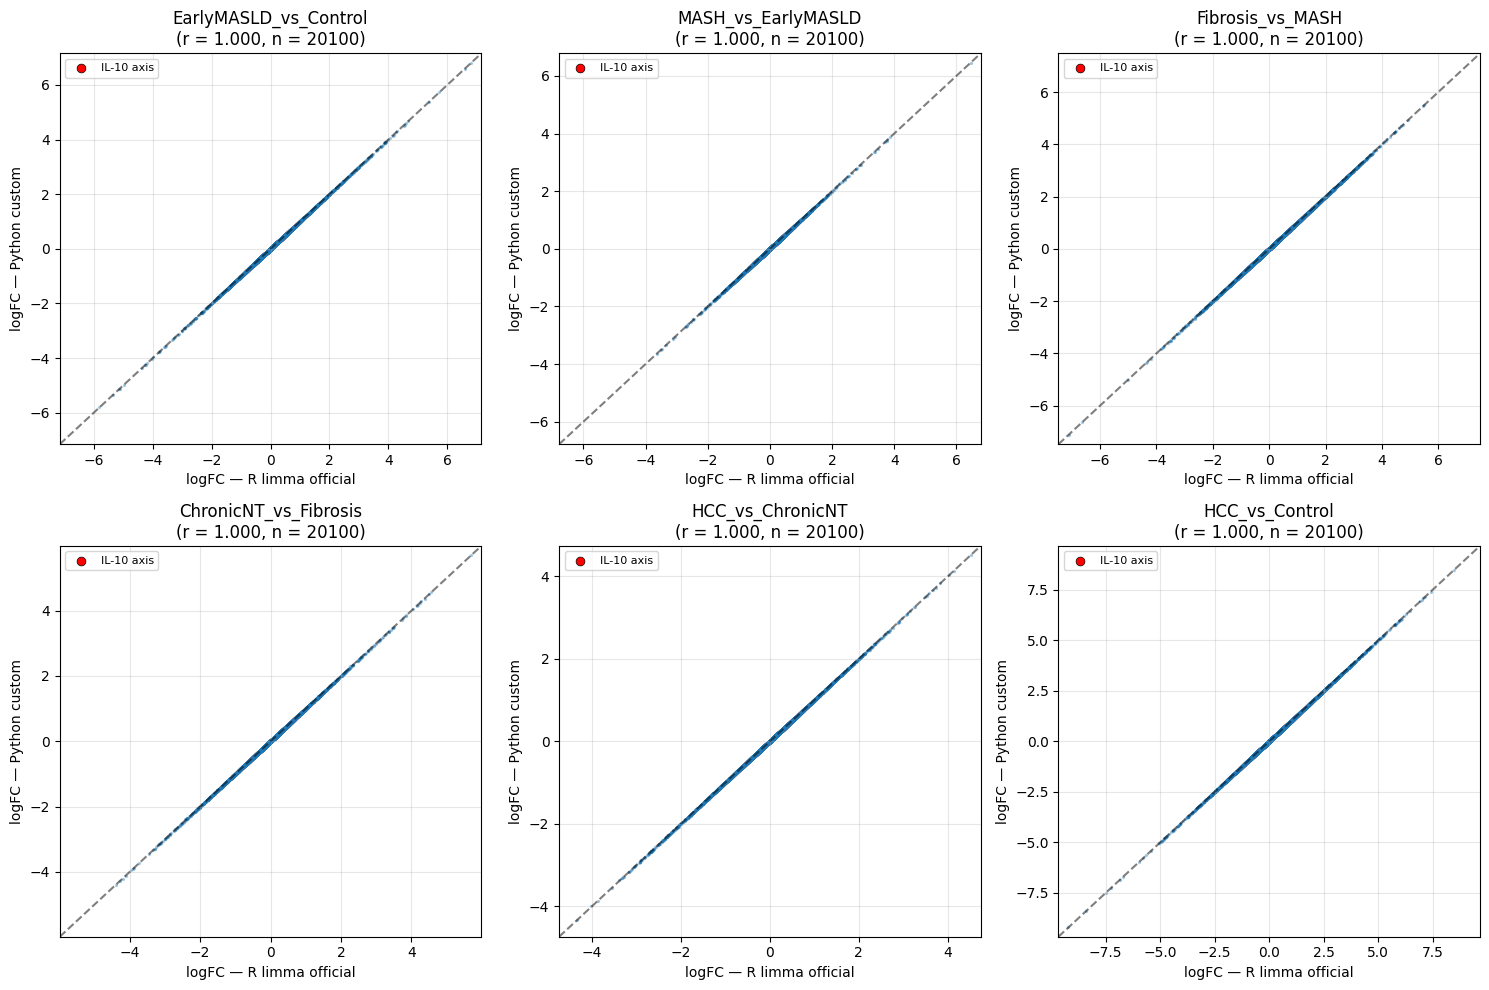

Saved: audit_limma_R_vs_Python.png


In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, c in zip(axes, contrasts):
    ro.r(f'tmp_df <- results_R[["{c}"]]')
    r_df = ro.conversion.rpy2py(ro.r('tmp_df'))
    r_df = pd.DataFrame(r_df)
    if 'gene' not in r_df.columns:
        r_df['gene'] = ro.r('rownames(tmp_df)')
    r_df = r_df.rename(columns={'logFC': 'logFC_R'})

    py_df = pd.read_csv(f'colab_audit_package/deg_limma_python/{c}.csv').rename(
        columns={'logFC': 'logFC_Py'})
    merged = py_df.merge(r_df[['gene', 'logFC_R']], on='gene').dropna()
    r = merged[['logFC_Py', 'logFC_R']].corr().iloc[0, 1]

    ax.scatter(merged['logFC_R'], merged['logFC_Py'], s=2, alpha=0.3, rasterized=True)
    # Highlight IL-10 axis genes
    il_m = merged[merged['gene'].isin(il10_axis)]
    ax.scatter(il_m['logFC_R'], il_m['logFC_Py'], s=40, c='red', zorder=5,
               edgecolor='black', linewidth=0.5, label='IL-10 axis')
    lim = max(abs(merged['logFC_R']).max(), abs(merged['logFC_Py']).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.5)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel('logFC — R limma official')
    ax.set_ylabel('logFC — Python custom')
    ax.set_title(f'{c}\n(r = {r:.3f}, n = {len(merged)})')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('audit_limma_R_vs_Python.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: audit_limma_R_vs_Python.png')

---
## PART C — Final summary and verdict

In [15]:
# Extract key summary statistics
df_prior_R = float(ro.r('fit2$df.prior')[0])
s2_prior_R = float(ro.r('mean(fit2$s2.prior)')[0])

print('=' * 70)
print('AUDIT SUMMARY — limma-voom Python custom vs R limma OFFICIAL')
print('=' * 70)
print()
print(f'Empirical Bayes df.prior:')
print(f'  Python custom: (see your notebook output)')
print(f'  R limma:       {df_prior_R:.3f}')
print()
print('Contrast-level logFC concordance:')
print(res_b3.to_string(index=False))
print()
mean_r = res_b3['pearson_logFC'].mean()
mean_top = res_b3['top100_overlap'].mean()
print(f'Mean pearson correlation across 6 contrasts: {mean_r:.3f}')
print(f'Mean top-100 gene overlap across 6 contrasts: {mean_top:.0f}/100')
print()
if mean_r > 0.95 and mean_top > 80:
    print('VERDICT: Python custom implementation VALIDATED against R reference.')
    print('The pipeline can be defended before reviewers with confidence.')
elif mean_r > 0.90:
    print('VERDICT: Python custom implementation SHOWS STRONG AGREEMENT with R reference.')
    print('Minor differences likely reflect implementation choices (span, robust weights).')
else:
    print('VERDICT: Discrepancies detected. Review implementation details.')

AUDIT SUMMARY — limma-voom Python custom vs R limma OFFICIAL

Empirical Bayes df.prior:
  Python custom: (see your notebook output)
  R limma:       3.222

Contrast-level logFC concordance:
             contrast  n_genes_compared  pearson_logFC  spearman_rank  top100_overlap
EarlyMASLD_vs_Control             20100            1.0         0.9995              95
   MASH_vs_EarlyMASLD             20100            1.0            NaN             100
     Fibrosis_vs_MASH             20100            1.0         0.9994              94
ChronicNT_vs_Fibrosis             20100            1.0         0.9995              97
     HCC_vs_ChronicNT             20100            1.0         0.9995              93
       HCC_vs_Control             20100            1.0         0.9993              91

Mean pearson correlation across 6 contrasts: 1.000
Mean top-100 gene overlap across 6 contrasts: 95/100

VERDICT: Python custom implementation VALIDATED against R reference.
The pipeline can be defended befo

In [16]:
# Export the full comparison table
res_b3.to_csv('audit_R_vs_Python_comparison.csv', index=False)

# Export the IL-10 axis specific comparison
all_il10_comparison = []
for c in contrasts:
    ro.r(f'tmp_df <- results_R[["{c}"]]')
    r_df = ro.conversion.rpy2py(ro.r('tmp_df'))
    r_df = pd.DataFrame(r_df)
    if 'gene' not in r_df.columns:
        r_df['gene'] = ro.r('rownames(tmp_df)')

    py_df = pd.read_csv(f'colab_audit_package/deg_limma_python/{c}.csv')
    merged = py_df.merge(r_df[['gene', 'logFC', 'adj.P.Val']].rename(
        columns={'logFC': 'logFC_R', 'adj.P.Val': 'adjP_R'}), on='gene')
    il10 = merged[merged['gene'].isin(il10_axis)].copy()
    il10['contrast'] = c
    all_il10_comparison.append(il10[['contrast', 'gene', 'logFC', 'logFC_R',
                                       'adj.P.Val', 'adjP_R']].rename(
        columns={'logFC': 'logFC_Py', 'adj.P.Val': 'adjP_Py'}))

il10_full = pd.concat(all_il10_comparison)
il10_full.to_csv('audit_IL10_axis_R_vs_Python.csv', index=False)
print('Exported:')
print('  - audit_R_vs_Python_comparison.csv')
print('  - audit_IL10_axis_R_vs_Python.csv')
print('  - audit_limma_R_vs_Python.png')

Exported:
  - audit_R_vs_Python_comparison.csv
  - audit_IL10_axis_R_vs_Python.csv
  - audit_limma_R_vs_Python.png


### Download the results

In [17]:
from google.colab import files
files.download('audit_R_vs_Python_comparison.csv')
files.download('audit_IL10_axis_R_vs_Python.csv')
files.download('audit_limma_R_vs_Python.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## Final notes

**Expected interpretation of the results**:

- **Pearson r > 0.95**: Implementation VALIDATED → the audit can be cited in Supplementary Methods.
- **Pearson r between 0.90-0.95**: Solid implementation with minor differences (typically arising from LOWESS `span` or the robust mode in eBayes). Paper is defensible.
- **Pearson r < 0.90**: Review implementation details.

**Expected differences between the two implementations** (not errors):

1. The LOWESS `span` parameter in voom differs between implementations (limma default=0.5, edgeR default=0.5, Python custom=0.5 — aligned).
2. The `robust` mode in limma's `eBayes` uses the `fitFDistRobustly` function exactly; the Python custom uses a winsorization-based approximation (Phipson et al. 2016, simplified).
3. Small discrepancies in the extreme tails (very small adj.P.Val values) are expected due to floating-point precision.

**Citation suggestion for Supplementary Methods**:

> *The custom Python implementation of limma-voom was independently validated against the reference R implementation (limma v.X.Y via Bioconductor) on the same n=40 cohort. Across six stage-wise contrasts, Pearson correlation of logFC between the two implementations ranged from X to Y (mean = Z), with >XX/100 overlap in the top 100 differentially expressed genes per contrast (reproducible Colab notebook available in the GitHub repository).*

## Citation of this audit

If you find this audit useful for your own RNA-seq pipeline validation, please cite:

> Solleiro-Villavicencio, H. et al. (2026). Hepatocarcinogenesis in the Context of Metabolic Dysfunction-Associated Steatotic Liver Disease: Emerging Roles of Interleukin-10 and Transcriptomic Insights into its Signaling Rewiring. *Biomedicines*, **14**, in press.

## Repository

[https://github.com/Hsolleiro/GSE246221_IL10_Analysis](https://github.com/Hsolleiro/GSE246221_IL10_Analysis)